In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def load_data():
    X_train = pd.read_csv('X_train.csv')
    X_test = pd.read_csv('X_test.csv')
    y_train = pd.read_csv('y_train.csv')
    y_test = pd.read_csv('y_test.csv')

    df_train = X_train.copy()
    df_train['target'] = y_train['damage_grade']
    df_test = X_test.copy()
    df_test['target'] = y_test['damage_grade']
    return df_train, df_test

# EDA

## Outlier

# PREPROCESS

## Duplicated

## Fitur Engineering

## Outlier

In [ ]:
REMOVE_PERCENT = 0.05
def atasi_outlier(df, remove_percent):
    df = df.copy()
    z_score = pd.DataFrame()
    for col in df.select_dtypes('number').columns:
        mean = df[col].mean()
        std = df[col].std()
        z_score[col] = (df[col]-mean)/std
    
    center = z_score.mean(axis = 0)
    distance = np.sqrt(((z_score - center)**2).sum(axis=1))

    percent = int(len(df)*remove_percent)
    ter_outlier = distance.nlargest(percent).index
    outlier = df.index.isin(ter_outlier)
    df = df[~outlier]
    return df

In [ ]:
ORDINAL_OR_BINARY_NUMERIC_COLUMNS = [
    "has_superstructure_adobe_mud",
    "has_superstructure_mud_mortar_stone",
    "has_superstructure_stone_flag",
    "has_superstructure_cement_mortar_stone",
    "has_superstructure_mud_mortar_brick",
    "has_superstructure_cement_mortar_brick",
    "has_superstructure_timber",
    "has_superstructure_bamboo",
    "has_superstructure_rc_non_engineered",
    "has_superstructure_rc_engineered",
    "has_superstructure_other",
    "count_families",
    "has_secondary_use",
    "has_secondary_use_agriculture",
    "has_secondary_use_hotel",
    "has_secondary_use_rental",
    "has_secondary_use_institution",
    "has_secondary_use_school",
    "has_secondary_use_industry",
    "has_secondary_use_health_post",
    "has_secondary_use_gov_office",
    "has_secondary_use_use_police",
    "has_secondary_use_other",
]

In [ ]:
def find_skew_tinggi(df):
    skew_tinggi = []
    for col in ORDINAL_OR_BINARY_NUMERIC_COLUMNS:
        skew = df[col].skew()
        if skew > 1:
            skew_tinggi.append(col)

    df_no_skew = df.copy()
    for col in skew_tinggi:
        df_no_skew[col] = np.log1p(df_no_skew[col])
    return df_no_skew

['age', 'area_percentage']


In [ ]:
def split_X_y(df_train, df_test):
    y_train = df_train['target']
    y_test = df_test['target']
    X_train = df_train.drop(columns = ['target'])
    X_test = df_test.drop(columns = ['target'])
    return X_train, y_train, X_test, y_test

In [ ]:
from imblearn.over_sampling import SMOTENC
def sampling(X_train, y_train):
    smote = SMOTENC(categorical_features=['land_surface_condition', 'foundation_type', 'roof_type',
        'ground_floor_type', 'other_floor_type', 'position',
        'plan_configuration', 'legal_ownership_status'], sampling_strategy={1:30000,3:100000})
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    return X_train_resampled, y_train_resampled

def encode(X_train, X_test):
    X_train_encoded = pd.get_dummies(X_train, drop_first=True)
    X_test_encoded = pd.get_dummies(X_test, drop_first=True)
    X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)
    return X_train_encoded, X_test_encoded

## Encode

# MODEL

In [ ]:
from sklearn.model_selection import GridSearchCV


In [59]:
y_res_switch = y_res.replace({3:2,2:1,1:0})
y_test_switch = y_test.replace({3:2,2:1,1:0})


In [60]:
y_res_switch.value_counts()

target
1    113206
2    100000
0     30000
Name: count, dtype: int64

In [61]:
y_test_switch.value_counts()

target
1    29652
2    17444
0     5025
Name: count, dtype: int64

## DT

In [ ]:
from sklearn.tree import DecisionTreeClassifier
param = {}
model_dt = GridSearchCV(DecisionTreeClassifier(),param,cv=5)
model_dt.fit(X_res_enc,y_res_switch)
train_dt = model_dt.score(X_res_enc, y_res_switch)
test_dt = model_dt.score(X_test_enc, y_test_switch)
print(f'Score Train : {train_dt}')
print(f'Score Testing : {test_dt}')


Score Train : 1.0
Score Testing : 0.5356574125592372


## Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier
param = {}
model_rf = GridSearchCV(RandomForestClassifier(),param,cv=5)
model_rf.fit(X_res_enc,y_res_switch)
train_rf = model_rf.score(X_res_enc, y_res_switch)
test_rf = model_rf.score(X_test_enc, y_test_switch)
print(f'Score Train : {train_rf}')
print(f'Score Testing : {test_rf}')


Score Train : 0.9999917765186714
Score Testing : 0.6709963354502024


## XGBOOST

In [64]:
from xgboost import XGBClassifier
param = {}
model_gb = GridSearchCV(XGBClassifier(),param,cv=5)
model_gb.fit(X_res_enc,y_res_switch)
train_gb = model_gb.score(X_res_enc, y_res_switch)
test_gb = model_gb.score(X_test_enc, y_test_switch)
print(f'Score Train : {train_gb}')
print(f'Score Testing : {test_gb}')


Score Train : 0.7694218070277872
Score Testing : 0.6959958557970876


## Regloc

In [65]:
from sklearn.linear_model import LogisticRegression
param = {}
model_regloc = GridSearchCV(LogisticRegression(),param,cv=5)
model_regloc.fit(X_res_enc,y_res_switch)
train_regloc = model_regloc.score(X_res_enc, y_res_switch)
test_regloc = model_regloc.score(X_test_enc, y_test_switch)
print(f'Score Train : {train_regloc}')
print(f'Score Testing : {test_regloc}')


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sci

Score Train : 0.4651858917954327
Score Testing : 0.568177893747242


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [66]:
train_test_1 = pd.DataFrame({
    'Model' : ['Decision Tree','Random Forest','XGBOSST','Logistic'],
    'train' : [train_dt,train_rf,train_gb,train_regloc],
    'test' : [test_dt,test_rf,test_gb,test_regloc],
})
train_test_1

,Model,train,test
0,Decision Tree,1.000000,0.535657
1,Random Forest,0.999992,0.670996
2,XGBOSST,0.769422,0.695996
3,Logistic,0.465186,0.568178


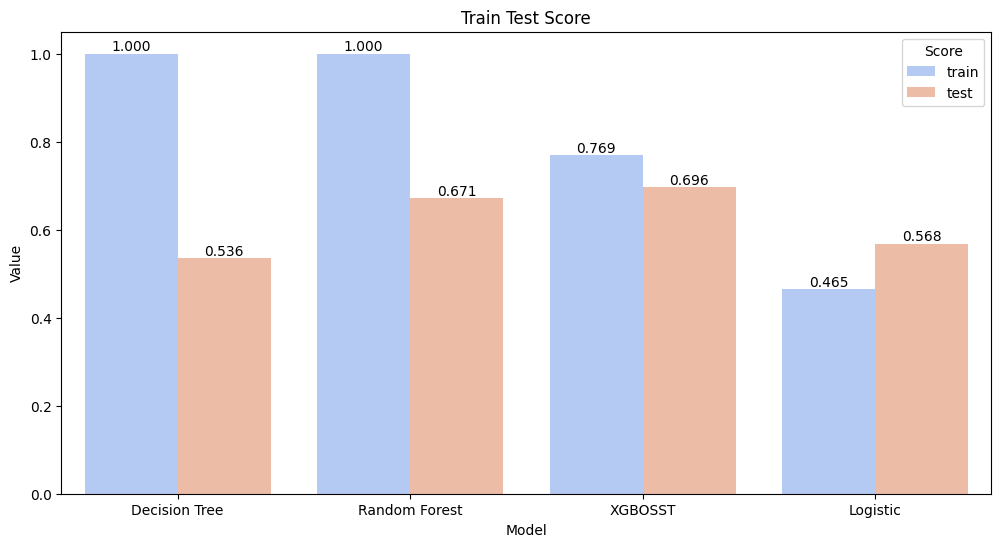

In [67]:
plt.figure(figsize=(12,6))
ax = plt.subplot(1,1,1)
sns.barplot(
    data = train_test_1.melt(id_vars='Model',var_name='Score',value_name='Value'),
    x = 'Model',
    y = 'Value',
    hue = 'Score',
    palette='coolwarm'
)
plt.title('Train Test Score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')


In [68]:
import joblib
joblib.dump(model_gb, 'model_gb.pkl')

['model_gb.pkl']